<a href="https://colab.research.google.com/github/Ritapaz/simulacao-logistica/blob/estoques/C%C3%B3pia_de_simula%C3%A7%C3%A3o.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
arquivo = "planilha_estoque_ficticia_100_produtos.xlsx"
produtos = pd.read_excel(arquivo, sheet_name = "Produtos")
produtos.head()


,Código,Produto,Categoria,Marca,Unidade,Cód. fornecedor,Fornecedor,Lead time (dias),Estoque inicial,Estoque mínimo,...,Estoque de segurança,Localização,Custo unitário (R$),Preço de venda (R$),Entradas 2025,Saídas 2025,Perdas 2025,Estoque atual,Status estoque,Valor em estoque (R$)
0,PRD001,Macarrão Max 12un,Alimentos,Prime,UN,FOR010,Fornecedor Nexus 10,10,139,35,...,23,A-09-3,17.72,25.53,328,142,0,325,Normal,5759.00
1,PRD002,Refrigerante Smart 12un,Bebidas,Delta,UN,FOR003,Fornecedor Beta 3,20,87,29,...,22,C-09-5,102.00,176.14,213,138,0,162,Normal,16524.00
2,PRD003,Condicionador Smart 1L,Higiene,Delta,UN,FOR009,Fornecedor Delta 9,9,20,5,...,3,C-04-1,209.96,359.29,246,88,5,173,Excesso,36323.08
3,PRD004,Álcool Plus 500ml,Limpeza,Econ,UN,FOR012,Fornecedor Gama 12,13,156,47,...,36,B-05-5,108.97,139.98,616,303,0,469,Excesso,51106.93
4,PRD005,Grampeador Premium 2L,Papelaria,Econ,UN,FOR012,Fornecedor Gama 12,13,115,27,...,13,A-06-1,71.33,124.65,365,225,1,254,Normal,18117.82


In [ ]:
produto = produtos.iloc[0]
produto

,0
Código,PRD001
Produto,Macarrão Max 12un
Categoria,Alimentos
Marca,Prime
Unidade,UN
Cód. fornecedor,FOR010
Fornecedor,Fornecedor Nexus 10
Lead time (dias),10
Estoque inicial,139
Estoque mínimo,35


In [ ]:
np.random.seed(10)

estoque = produto["Estoque inicial"]
estoque_minimo = produto["Estoque mínimo"]
custo = produto["Custo unitário (R$)"]
print(estoque)

historico = []

for dia in range(30):
  demanda =  np.random.randint(5,20)

  if demanda > estoque:
    ruptura = demanda - estoque
    venda_real = estoque
    estoque = 0
  else:
    ruptura = 0
    venda_real = demanda
    estoque -= demanda

  valor =estoque * custo

  historico.append([dia+1, demanda, estoque, venda_real, ruptura, valor])

df = pd.DataFrame(historico, columns = ["Dia", "Demanda", "Estoque", "Venda real", "Ruptura", "Valor"])

df


139


,Dia,Demanda,Estoque,Venda real,Ruptura,Valor
0,1,14,125,14,0,2215.00
1,2,18,107,18,0,1896.04
2,3,9,98,9,0,1736.56
3,4,5,93,5,0,1647.96
4,5,6,87,6,0,1541.64
5,6,16,71,16,0,1258.12
6,7,17,54,17,0,956.88
7,8,14,40,14,0,708.80
8,9,18,22,18,0,389.84
9,10,5,17,5,0,301.24


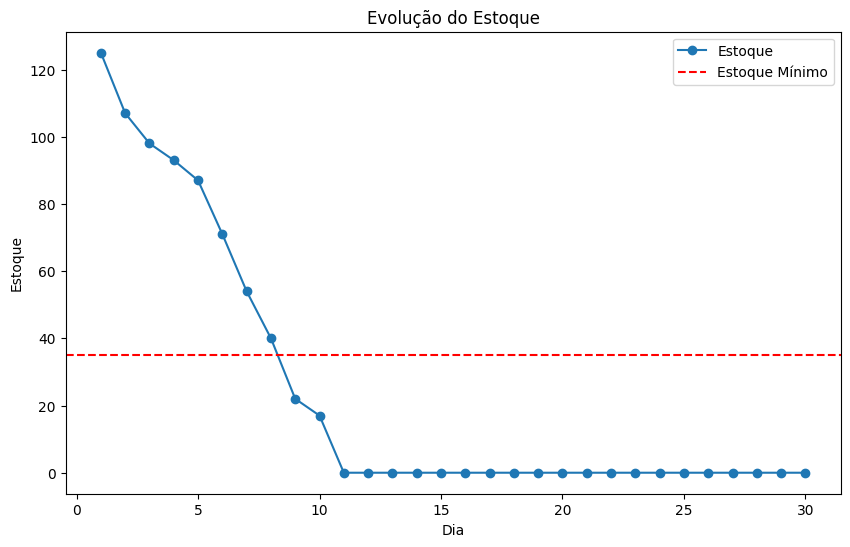

In [ ]:
plt.figure(figsize=(10,6))
plt.plot(df["Dia"], df["Estoque"], label = "Estoque", marker='o')
plt.axhline(estoque_minimo, color='r', linestyle='--', label='Estoque Mínimo')
plt.xlabel("Dia")
plt.ylabel("Estoque")
plt.title("Evolução do Estoque")
plt.legend()

In [ ]:
print("Ruptura total:", df["Ruptura"].sum())
print("Valor Médio em estoque: R$", round(df["Valor"].mean(),2))
print("Estoque médio:", df["Estoque"].mean())

Ruptura total: 220
Valor Médio em estoque: R$ 421.74
Estoque médio: 23.8
